<a href="https://colab.research.google.com/github/CHAKRI-GUPTHA/L2_regularization.ipynb/blob/main/L2_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - loss: 0.2946 - val_loss: 0.1984
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - loss: 0.1827 - val_loss: 0.1705
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - loss: 0.1664 - val_loss: 0.1612
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - loss: 0.1600 - val_loss: 0.1565
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - loss: 0.1567 - val_loss: 0.1544
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - loss: 0.1547 - val_loss: 0.1520
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - loss: 0.1534 - val_loss: 0.1513
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - loss: 0.1526 - val_loss: 0.1510
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - loss: 0.1519 - val_loss: 0.1499
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - loss: 0.1515 - val_loss: 0.1503
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - loss: 0.151

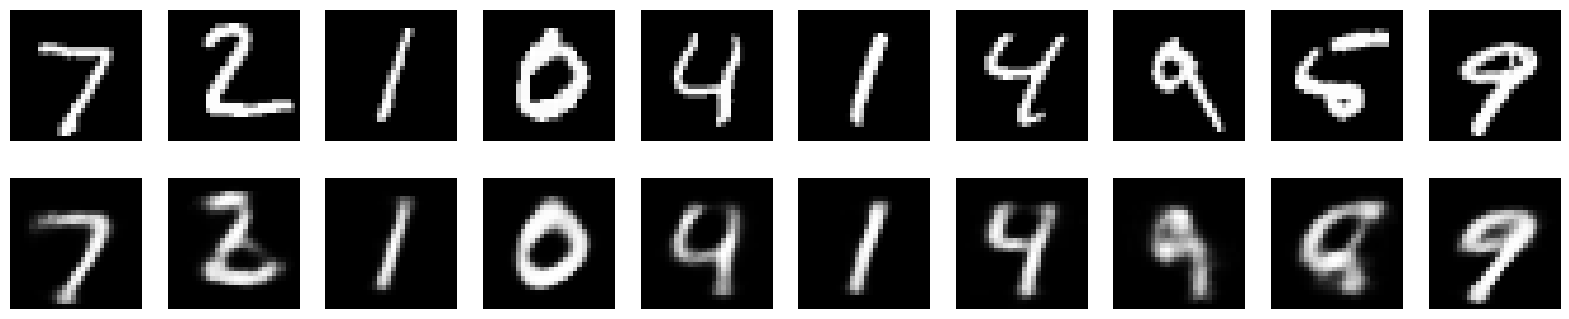

In [2]:
############
#
# Regularized Deep Autoencoder
# (with L2 weight decay)
#
############

### Import libraries
import tensorflow as tf
from tensorflow import keras
from keras import layers, regularizers
import matplotlib.pyplot as plt
import numpy as np

### Load MNIST dataset
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize pixel values to range 0–1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images from 28x28 → 784 pixels
x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

### Hyperparameters
input_dim = 784          # 28x28 images
encoding_dim1 = 512       # first hidden layer
encoding_dim2 = 256       # second hidden layer (bottleneck)
encoding_dim3 = 128       # third hidden layer (optional smaller bottleneck)
reg_factor = 1e-4        # L2 regularization factor

### Encoder
input_img = keras.Input(shape=(input_dim,))

# First hidden layer with L2 regularization
encoded = layers.Dense(
    encoding_dim1,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(input_img)

# Second hidden layer
encoded = layers.Dense(
    encoding_dim2,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(encoded)

# Third hidden layer (bottleneck)
encoded = layers.Dense(
    encoding_dim3,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(encoded)

### Decoder
# Mirror the encoder architecture
decoded = layers.Dense(
    encoding_dim2,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(encoded)

decoded = layers.Dense(
    encoding_dim1,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(decoded)

# Output layer reconstructs original 784-pixel image
decoded = layers.Dense(
    input_dim,
    activation="sigmoid",
    kernel_regularizer=regularizers.l2(reg_factor)
)(decoded)

### Autoencoder model
autoencoder = keras.Model(inputs=input_img, outputs=decoded)

### Compile model
# optimizer=adam → standard choice for training deep networks
# loss=binary_crossentropy → works well for normalized pixel values
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

### Train model
history = autoencoder.fit(
    x_train, x_train,             # input = output for autoencoder
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

### Reconstruct test images
decoded_imgs = autoencoder.predict(x_test)

### Plot original vs reconstructed images
n = 10  # number of images to display
plt.figure(figsize=(20,4))
for i in range(n):
    # Original image
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.axis("off")

    # Reconstructed image
    ax = plt.subplot(2, n, i+n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.show()